In [17]:
#  STUDENT PERFORMANCE — DATA ANALYSIS & VISUALIZATION DASHBOARD
#  Algorithms: Logistic Regression | Decision Tree | Random Forest
#  Target    : Pass / Fail Classification (G3 >= 10 → Pass)

#  1: IMPORTS 
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [18]:
# DASHBOARD THEME 
DARK   = '#12131a'
PANEL  = '#1c1f2e'
CARD   = '#252840'
BLUE   = '#4f8ef7'
GREEN  = '#3ecf8e'
RED    = '#f2637a'
YELLOW = '#f5c542'
PURPLE = '#a78bfa'
TEXT   = '#e8eaf0'
MUTED  = '#8b8fa8'

plt.rcParams.update({
    'figure.facecolor' : DARK,
    'axes.facecolor'   : PANEL,
    'axes.edgecolor'   : CARD,
    'axes.labelcolor'  : MUTED,
    'text.color'       : TEXT,
    'xtick.color'      : MUTED,
    'ytick.color'      : MUTED,
    'grid.color'       : CARD,
    'grid.linewidth'   : 0.5,
    'font.size'        : 10,
})

print("  Libraries loaded. Dashboard theme applied.")

  Libraries loaded. Dashboard theme applied.


In [19]:
# 2: LOAD DATA
mat = pd.read_csv('student-mat.csv', sep=',')   # ← change ; to ,
por = pd.read_csv('student-por.csv', sep=',')   # ← change ; to ,

df = mat.copy()
df['pass_fail']   = (df['G3'] >= 10).astype(int)
df['outcome_lbl'] = df['pass_fail'].map({1: 'Pass', 0: 'Fail'})

vc = df['pass_fail'].value_counts()
print(f"\nDataset : {df.shape[0]} students × {df.shape[1]} columns")
print(f"Missing : {df.isnull().sum().sum()} | Duplicates: {df.duplicated().sum()}")
print(f"Pass    : {vc[1]} ({vc[1]/len(df)*100:.1f}%)  |  Fail: {vc[0]} ({vc[0]/len(df)*100:.1f}%)")


Dataset : 395 students × 35 columns
Missing : 0 | Duplicates: 0
Pass    : 265 (67.1%)  |  Fail: 130 (32.9%)


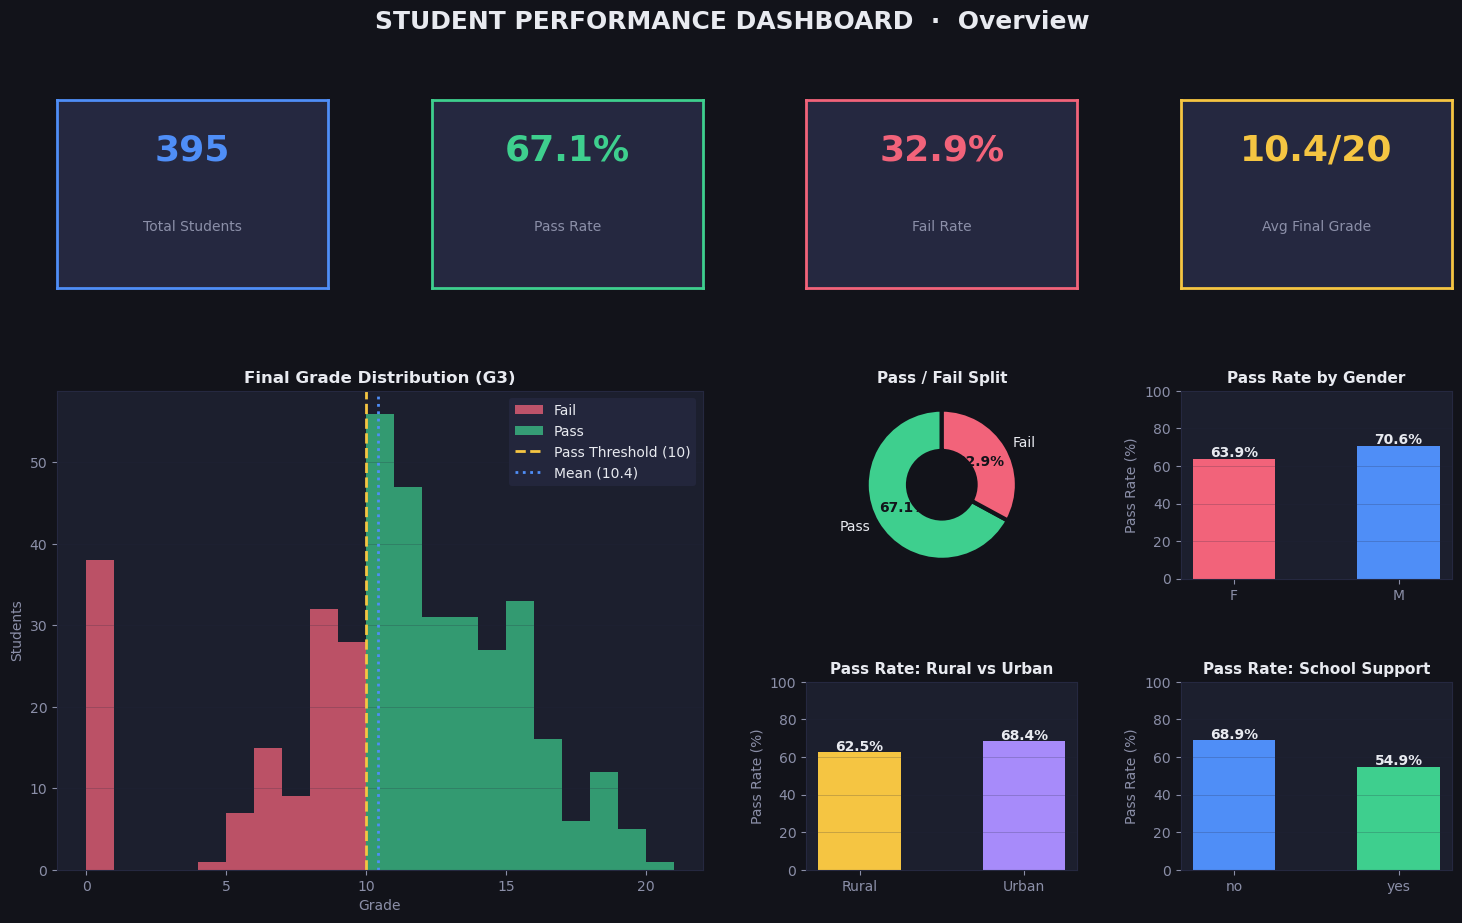

 Panel 1 — Overview done.


In [20]:
# 3: DASHBOARD PANEL 1 — OVERVIEW KPIs
fig = plt.figure(figsize=(18, 10), facecolor=DARK)
fig.suptitle('STUDENT PERFORMANCE DASHBOARD  ·  Overview',
             fontsize=18, fontweight='bold', color=TEXT, y=0.97)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38)

# KPI Cards
kpis = [
    ('Total Students',  str(len(df)),                    BLUE,   ),
    ('Pass Rate',       f'{vc[1]/len(df)*100:.1f}%',     GREEN,  ),
    ('Fail Rate',       f'{vc[0]/len(df)*100:.1f}%',     RED,    ),
    ('Avg Final Grade', f'{df["G3"].mean():.1f}/20',     YELLOW, ),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_color(color); sp.set_linewidth(2)
    ax.text(0.5, 0.68, val,   transform=ax.transAxes, ha='center',
            fontsize=26, fontweight='bold', color=color)
    ax.text(0.5, 0.30, label, transform=ax.transAxes, ha='center',
            fontsize=10, color=MUTED)

    
# Grade Distribution
ax1 = fig.add_subplot(gs[1:, 0:2])
ax1.set_facecolor(PANEL)
ax1.hist(df[df['pass_fail']==0]['G3'], bins=range(0,22), color=RED,   alpha=0.75, label='Fail', edgecolor='none')
ax1.hist(df[df['pass_fail']==1]['G3'], bins=range(0,22), color=GREEN, alpha=0.70, label='Pass', edgecolor='none')
ax1.axvline(10, color=YELLOW, linestyle='--', linewidth=2, label='Pass Threshold (10)')
ax1.axvline(df['G3'].mean(), color=BLUE, linestyle=':', linewidth=2, label=f'Mean ({df["G3"].mean():.1f})')
ax1.set_title('Final Grade Distribution (G3)', color=TEXT, fontsize=12, fontweight='bold')
ax1.set_xlabel('Grade'); ax1.set_ylabel('Students')
ax1.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax1.grid(True, axis='y', alpha=0.3)

# Donut
ax2 = fig.add_subplot(gs[1, 2])
ax2.set_facecolor(PANEL)
wedges, texts, autotexts = ax2.pie(
    [vc[1], vc[0]], labels=['Pass','Fail'], colors=[GREEN, RED],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=DARK, linewidth=3),
    textprops=dict(color=TEXT, fontsize=10))
for at in autotexts: at.set_color(DARK); at.set_fontweight('bold')
ax2.set_title('Pass / Fail Split', color=TEXT, fontsize=11, fontweight='bold')

# Gender vs Pass Rate
ax3 = fig.add_subplot(gs[1, 3])
ax3.set_facecolor(PANEL)
gp = df.groupby('sex')['pass_fail'].mean() * 100
bars = ax3.bar(gp.index, gp.values, color=[RED, BLUE], edgecolor='none', width=0.5)
for b, v in zip(bars, gp.values):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%', ha='center', color=TEXT, fontsize=10, fontweight='bold')
ax3.set_title('Pass Rate by Gender', color=TEXT, fontsize=11, fontweight='bold')
ax3.set_ylabel('Pass Rate (%)'); ax3.set_ylim(0, 100)
ax3.grid(True, axis='y', alpha=0.3)


# Address vs Pass Rate
ax4 = fig.add_subplot(gs[2, 2])
ax4.set_facecolor(PANEL)
ap = df.groupby('address')['pass_fail'].mean() * 100
bars = ax4.bar(['Rural','Urban'], ap.values, color=[YELLOW, PURPLE], edgecolor='none', width=0.5)
for b, v in zip(bars, ap.values):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%', ha='center', color=TEXT, fontsize=10, fontweight='bold')
ax4.set_title('Pass Rate: Rural vs Urban', color=TEXT, fontsize=11, fontweight='bold')
ax4.set_ylabel('Pass Rate (%)'); ax4.set_ylim(0, 100)
ax4.grid(True, axis='y', alpha=0.3)


# School Support vs Pass Rate
ax5 = fig.add_subplot(gs[2, 3])
ax5.set_facecolor(PANEL)
sp = df.groupby('schoolsup')['pass_fail'].mean() * 100
bars = ax5.bar(sp.index, sp.values, color=[BLUE, GREEN], edgecolor='none', width=0.5)
for b, v in zip(bars, sp.values):
    ax5.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%', ha='center', color=TEXT, fontsize=10, fontweight='bold')
ax5.set_title('Pass Rate: School Support', color=TEXT, fontsize=11, fontweight='bold')
ax5.set_ylabel('Pass Rate (%)'); ax5.set_ylim(0, 100)
ax5.grid(True, axis='y', alpha=0.3)

plt.savefig('dashboard_overview.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Panel 1 — Overview done.")


    

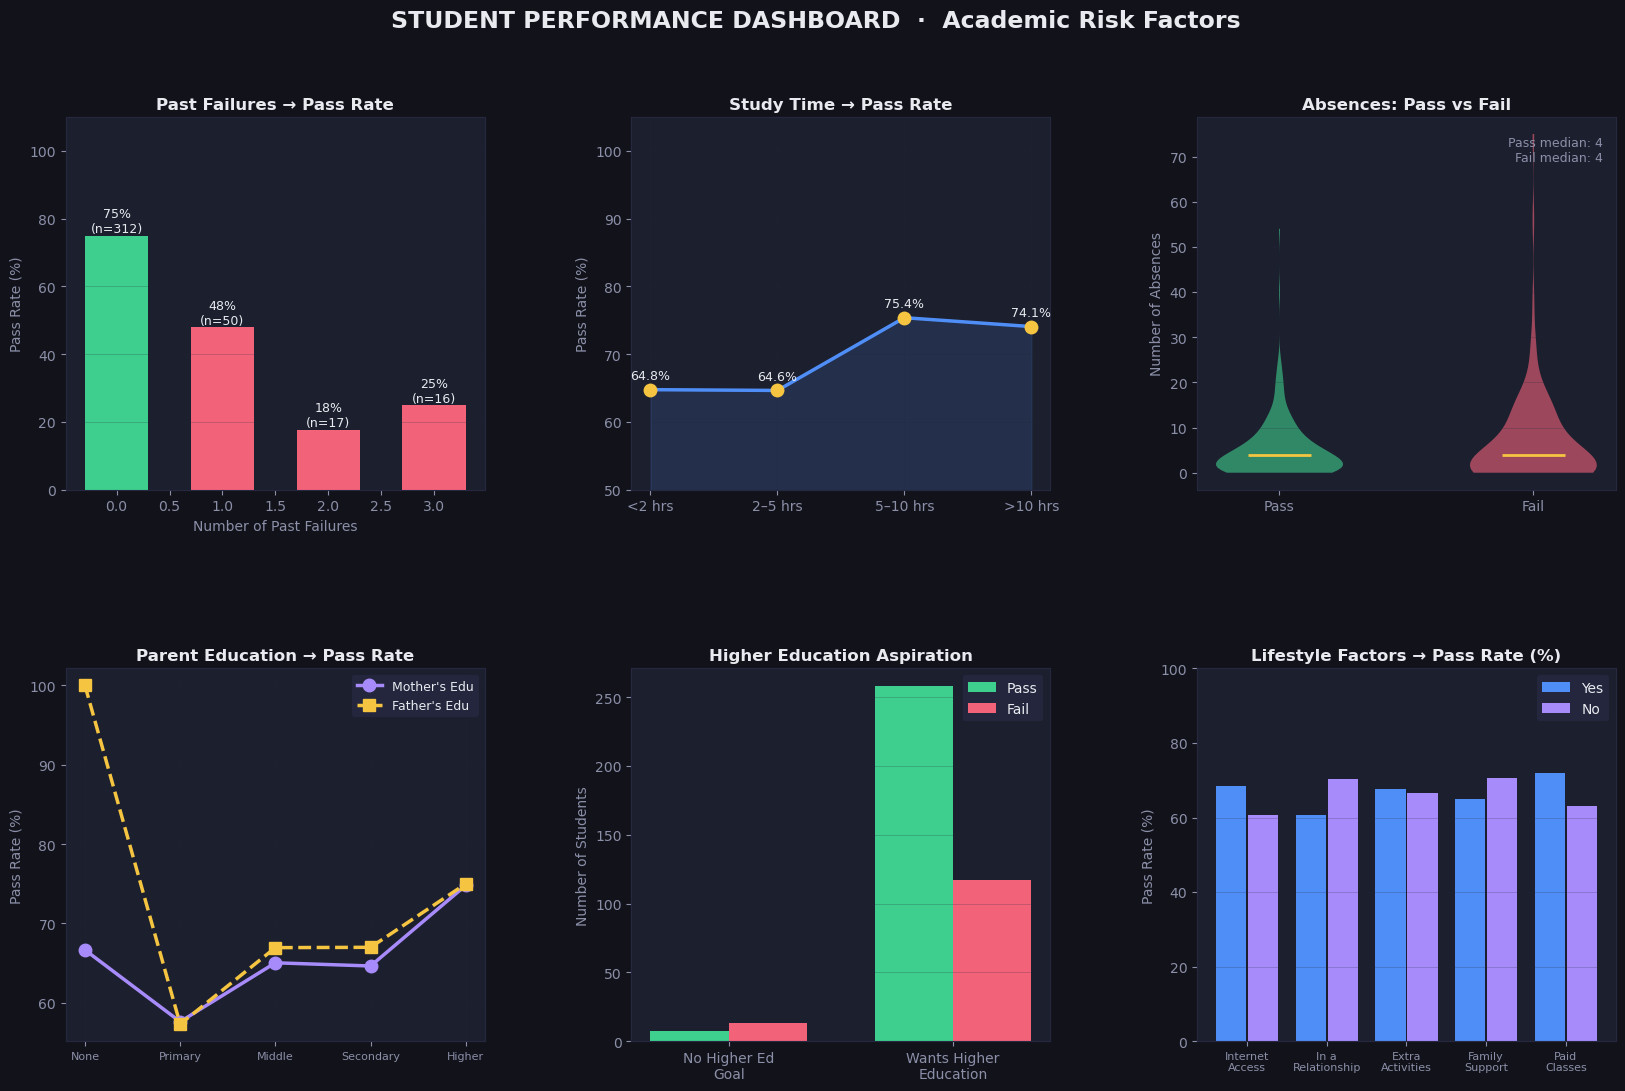

 Panel 2 — Risk Factors done.


In [21]:
# 4: DASHBOARD PANEL 2 — RISK FACTORS
fig = plt.figure(figsize=(20, 12), facecolor=DARK)
fig.suptitle('STUDENT PERFORMANCE DASHBOARD  ·  Academic Risk Factors',
             fontsize=17, fontweight='bold', color=TEXT, y=0.97)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

# Failures vs Pass Rate
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)
fp = df.groupby('failures')['pass_fail'].agg(['mean','count'])
fp['mean'] *= 100
bc = [GREEN if v > 50 else RED for v in fp['mean']]
bars = ax1.bar(fp.index, fp['mean'], color=bc, edgecolor='none', width=0.6)
for b, (idx, row) in zip(bars, fp.iterrows()):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f'{row["mean"]:.0f}%\n(n={int(row["count"])})', ha='center', color=TEXT, fontsize=9)
ax1.set_title('Past Failures → Pass Rate', color=TEXT, fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Past Failures'); ax1.set_ylabel('Pass Rate (%)')
ax1.set_ylim(0, 110); ax1.grid(True, axis='y', alpha=0.3)

# Study Time vs Pass Rate
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PANEL)
stp = df.groupby('studytime')['pass_fail'].mean() * 100
ax2.plot(stp.index, stp.values, 'o-', color=BLUE, linewidth=2.5, markersize=10,
         markerfacecolor=YELLOW, markeredgewidth=0)
ax2.fill_between(stp.index, stp.values, alpha=0.15, color=BLUE)
for x, y in zip(stp.index, stp.values):
    ax2.text(x, y+1.5, f'{y:.1f}%', ha='center', color=TEXT, fontsize=9)
ax2.set_xticks([1,2,3,4])
ax2.set_xticklabels(['<2 hrs','2–5 hrs','5–10 hrs','>10 hrs'])
ax2.set_title('Study Time → Pass Rate', color=TEXT, fontsize=12, fontweight='bold')
ax2.set_ylabel('Pass Rate (%)'); ax2.set_ylim(50, 105)
ax2.grid(True, alpha=0.3)

# Absences violin
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(PANEL)
pass_abs = df[df['pass_fail']==1]['absences']
fail_abs = df[df['pass_fail']==0]['absences']
vp = ax3.violinplot([pass_abs, fail_abs], positions=[1,2], showmedians=True, showextrema=False)
for body, color in zip(vp['bodies'], [GREEN, RED]):
    body.set_facecolor(color); body.set_alpha(0.6)
vp['cmedians'].set_color(YELLOW); vp['cmedians'].set_linewidth(2)
ax3.set_xticks([1,2]); ax3.set_xticklabels(['Pass','Fail'])
ax3.set_title('Absences: Pass vs Fail', color=TEXT, fontsize=12, fontweight='bold')
ax3.set_ylabel('Number of Absences'); ax3.grid(True, axis='y', alpha=0.3)
ax3.text(0.97, 0.95, f'Pass median: {pass_abs.median():.0f}\nFail median: {fail_abs.median():.0f}',
         transform=ax3.transAxes, ha='right', va='top', color=MUTED, fontsize=9)


# Parent Education vs Pass Rate
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(PANEL)
medu_p = df.groupby('Medu')['pass_fail'].mean() * 100
fedu_p = df.groupby('Fedu')['pass_fail'].mean() * 100
ax4.plot(medu_p.index, medu_p.values, 'o-', color=PURPLE, linewidth=2.5, markersize=9, label="Mother's Edu")
ax4.plot(fedu_p.index, fedu_p.values, 's--', color=YELLOW, linewidth=2.5, markersize=9, label="Father's Edu")
ax4.set_xticks([0,1,2,3,4])
ax4.set_xticklabels(['None','Primary','Middle','Secondary','Higher'], fontsize=8)
ax4.set_title("Parent Education → Pass Rate", color=TEXT, fontsize=12, fontweight='bold')
ax4.set_ylabel('Pass Rate (%)')
ax4.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT, fontsize=9)
ax4.grid(True, alpha=0.3)


# Higher Education aspiration
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(PANEL)
hp = df.groupby(['higher','outcome_lbl']).size().unstack(fill_value=0)
x = np.arange(2); w = 0.35
if 'Pass' in hp.columns and 'Fail' in hp.columns:
    ax5.bar(x - w/2, hp['Pass'], width=w, color=GREEN, label='Pass', edgecolor='none')
    ax5.bar(x + w/2, hp['Fail'], width=w, color=RED,   label='Fail', edgecolor='none')
ax5.set_xticks(x); ax5.set_xticklabels(['No Higher Ed\nGoal', 'Wants Higher\nEducation'])
ax5.set_title('Higher Education Aspiration', color=TEXT, fontsize=12, fontweight='bold')
ax5.set_ylabel('Number of Students')
ax5.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax5.grid(True, axis='y', alpha=0.3)


# Lifestyle factors vs Pass Rate
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(PANEL)
cats = ['internet','romantic','activities','famsup','paid']
cat_labels = ['Internet\nAccess','In a\nRelationship','Extra\nActivities','Family\nSupport','Paid\nClasses']
pr_yes = [df[df[c]=='yes']['pass_fail'].mean()*100 for c in cats]
pr_no  = [df[df[c]=='no']['pass_fail'].mean()*100  for c in cats]
x6 = np.arange(len(cats))
ax6.bar(x6 - 0.2, pr_yes, width=0.38, color=BLUE,   label='Yes', edgecolor='none')
ax6.bar(x6 + 0.2, pr_no,  width=0.38, color=PURPLE, label='No',  edgecolor='none')
ax6.set_xticks(x6); ax6.set_xticklabels(cat_labels, fontsize=8)
ax6.set_title('Lifestyle Factors → Pass Rate (%)', color=TEXT, fontsize=12, fontweight='bold')
ax6.set_ylabel('Pass Rate (%)'); ax6.set_ylim(0, 100)
ax6.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax6.grid(True, axis='y', alpha=0.3)

plt.savefig('dashboard_risk.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Panel 2 — Risk Factors done.")


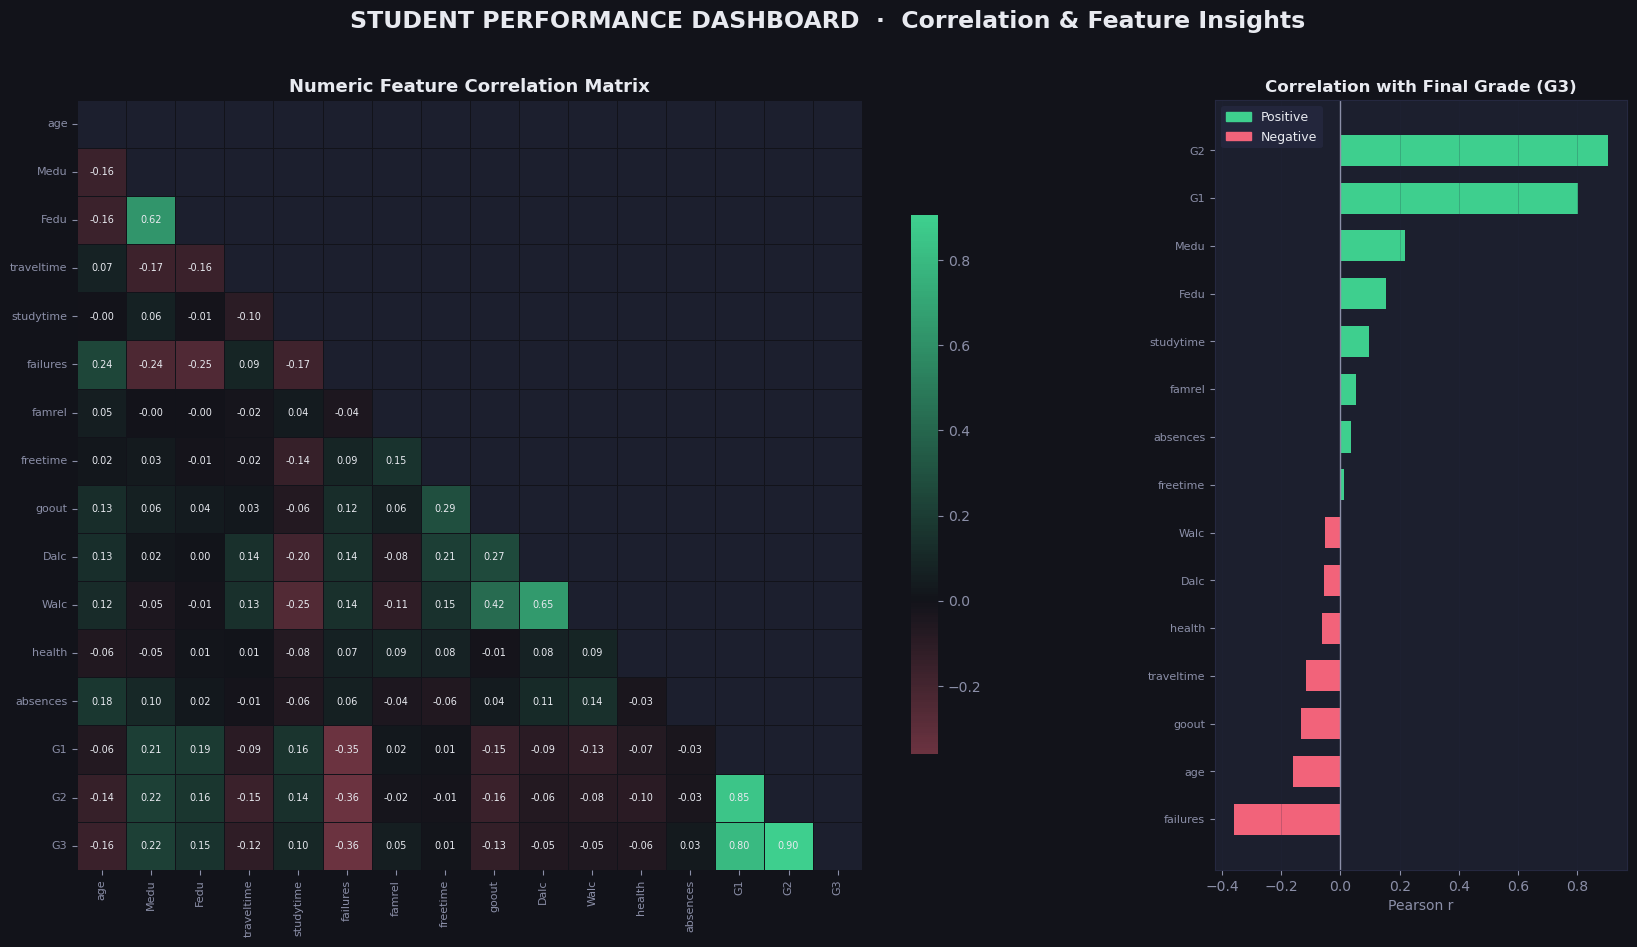

 Panel 3 — Correlation done.


In [22]:
#5: DASHBOARD PANEL 3 — CORRELATION ANALYSIS
fig = plt.figure(figsize=(20, 10), facecolor=DARK)
fig.suptitle('STUDENT PERFORMANCE DASHBOARD  ·  Correlation & Feature Insights',
             fontsize=17, fontweight='bold', color=TEXT, y=0.97)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

num_df   = df.select_dtypes(include=np.number).drop(columns=['pass_fail'], errors='ignore')
corr_mat = num_df.corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
cmap_div = LinearSegmentedColormap.from_list('custom', [RED, DARK, GREEN], N=256)

ax1 = fig.add_subplot(gs[0, 0:2])
ax1.set_facecolor(PANEL)
sns.heatmap(corr_mat, mask=mask, ax=ax1, cmap=cmap_div, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7, 'color': TEXT},
            linewidths=0.4, linecolor=DARK, cbar_kws={'shrink': 0.7})
ax1.set_title('Numeric Feature Correlation Matrix', color=TEXT, fontsize=13, fontweight='bold')
ax1.tick_params(labelsize=8)

ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PANEL)
g3_corr = corr_mat['G3'].drop('G3').sort_values()
bc_corr = [GREEN if v > 0 else RED for v in g3_corr.values]
ax2.barh(range(len(g3_corr)), g3_corr.values, color=bc_corr, edgecolor='none', height=0.65)
ax2.set_yticks(range(len(g3_corr))); ax2.set_yticklabels(g3_corr.index, fontsize=8)
ax2.axvline(0, color=MUTED, linewidth=1)
ax2.set_title('Correlation with Final Grade (G3)', color=TEXT, fontsize=12, fontweight='bold')
ax2.set_xlabel('Pearson r'); ax2.grid(True, axis='x', alpha=0.3)
ax2.legend(handles=[mpatches.Patch(color=GREEN, label='Positive'),
                    mpatches.Patch(color=RED,   label='Negative')],
           facecolor=CARD, edgecolor='none', labelcolor=TEXT, fontsize=9)

plt.savefig('dashboard_corr.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Panel 3 — Correlation done.")

In [23]:
# 6: PREPROCESSING & FEATURE ENGINEERING
df_ml = df.drop(columns=['outcome_lbl']).copy()

df_ml['grade_trend']    = df_ml['G2'] - df_ml['G1']
df_ml['avg_parent_edu'] = (df_ml['Medu'] + df_ml['Fedu']) / 2
df_ml['risk_score']     = df_ml['failures'] + df_ml['absences'] / 10 + df_ml['Dalc']
df_ml['support_score']  = ((df_ml['schoolsup']=='yes').astype(int) +
                            (df_ml['famsup']=='yes').astype(int) +
                            (df_ml['paid']=='yes').astype(int))

le = LabelEncoder()
for col in df_ml.select_dtypes(include=object).columns:
    df_ml[col] = le.fit_transform(df_ml[col])

FEATURES = [c for c in df_ml.columns if c not in ['G3', 'pass_fail']]
X = df_ml[FEATURES]
y = df_ml['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nPreprocessing done.")
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}  |  Features: {len(FEATURES)}")


Preprocessing done.
Train: 316  |  Test: 79  |  Features: 36


In [24]:
# 7: TRAIN MODELS
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=150, max_depth=7,
                                                   random_state=42, n_jobs=-1),
}

results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'Model':<22} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8} {'AUC':>8} {'CV-Acc':>9}")
print('─' * 80)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    yp  = model.predict(X_test_sc)
    ypr = model.predict_proba(X_test_sc)[:,1]
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp)
    rec  = recall_score(y_test, yp)
    f1   = f1_score(y_test, yp)
    auc  = roc_auc_score(y_test, ypr)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='accuracy').mean()
    results[name] = dict(acc=acc, prec=prec, rec=rec, f1=f1,
                          auc=auc, cv=cv, pred=yp, prob=ypr, model=model)
    print(f'{name:<22} {acc:>10.4f} {prec:>11.4f} {rec:>8.4f} {f1:>8.4f} {auc:>8.4f} {cv:>9.4f}')

best = max(results, key=lambda k: results[k]['f1'])
print(f'\n  Best Model (F1): {best}  —  F1 = {results[best]["f1"]:.4f}')


Model                    Accuracy   Precision   Recall       F1      AUC    CV-Acc
────────────────────────────────────────────────────────────────────────────────
Logistic Regression        0.8861      0.9583   0.8679   0.9109   0.9478    0.8956
Decision Tree              0.8861      0.9231   0.9057   0.9143   0.9162    0.9144
Random Forest              0.8861      0.9583   0.8679   0.9109   0.9492    0.9272

  Best Model (F1): Decision Tree  —  F1 = 0.9143


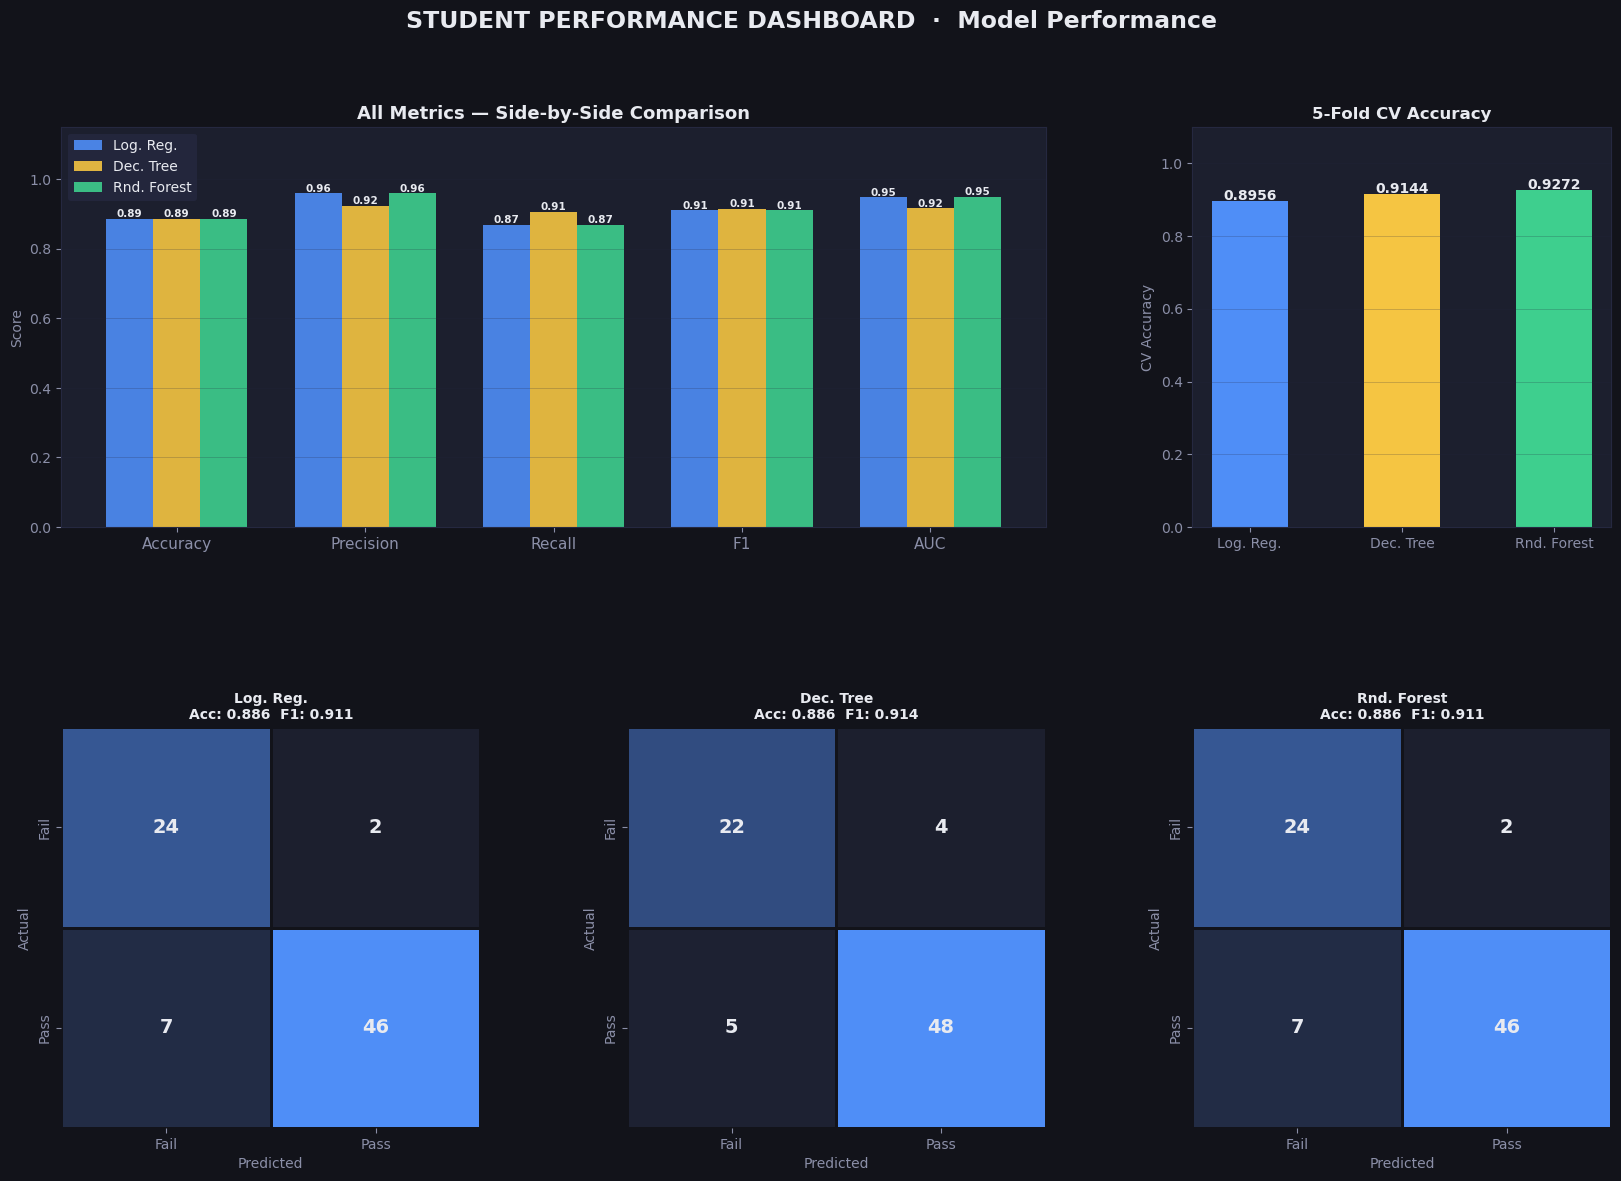

 Panel 4 — Model Performance done.


In [25]:
# 8: DASHBOARD PANEL 4 — MODEL PERFORMANCE

fig = plt.figure(figsize=(20, 13), facecolor=DARK)
fig.suptitle('STUDENT PERFORMANCE DASHBOARD  ·  Model Performance',
             fontsize=17, fontweight='bold', color=TEXT, y=0.97)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

model_names = list(results.keys())
short_names = ['Log. Reg.', 'Dec. Tree', 'Rnd. Forest']
m_colors    = [BLUE, YELLOW, GREEN]
metrics_k   = ['acc', 'prec', 'rec', 'f1', 'auc']
metric_lbls = ['Accuracy','Precision','Recall','F1','AUC']

# Grouped bar — all metrics
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.set_facecolor(PANEL)
x = np.arange(len(metrics_k)); w = 0.25
for i, (name, sname, color) in enumerate(zip(model_names, short_names, m_colors)):
    vals   = [results[name][m] for m in metrics_k]
    offset = (i - 1) * w
    bars   = ax1.bar(x + offset, vals, width=w, color=color, edgecolor='none', label=sname, alpha=0.9)
    for b, v in zip(bars, vals):
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f'{v:.2f}', ha='center', fontsize=7.5, color=TEXT, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(metric_lbls, fontsize=11)
ax1.set_ylim(0, 1.15); ax1.set_ylabel('Score')
ax1.set_title('All Metrics — Side-by-Side Comparison', color=TEXT, fontsize=13, fontweight='bold')
ax1.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT)
ax1.grid(True, axis='y', alpha=0.3)

# CV Accuracy
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PANEL)
cv_vals = [results[n]['cv'] for n in model_names]
bars = ax2.bar(short_names, cv_vals, color=m_colors, edgecolor='none', width=0.5)
for b, v in zip(bars, cv_vals):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
             f'{v:.4f}', ha='center', color=TEXT, fontsize=10, fontweight='bold')
ax2.set_ylim(0, 1.1); ax2.set_title('5-Fold CV Accuracy', color=TEXT, fontsize=12, fontweight='bold')
ax2.set_ylabel('CV Accuracy'); ax2.grid(True, axis='y', alpha=0.3)

# Confusion matrices
cmap_cm = LinearSegmentedColormap.from_list('cm', [PANEL, BLUE], N=256)
for i, (name, sname) in enumerate(zip(model_names, short_names)):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor(PANEL)
    cm = confusion_matrix(y_test, results[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_cm,
                xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'],
                ax=ax, linewidths=1, linecolor=DARK, cbar=False,
                annot_kws={'size': 14, 'color': TEXT, 'weight': 'bold'})
    ax.set_title(f'{sname}\nAcc: {results[name]["acc"]:.3f}  F1: {results[name]["f1"]:.3f}',
                 color=TEXT, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', color=MUTED)
    ax.set_ylabel('Actual', color=MUTED)
    ax.tick_params(colors=MUTED)

plt.savefig('dashboard_models.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Panel 4 — Model Performance done.")




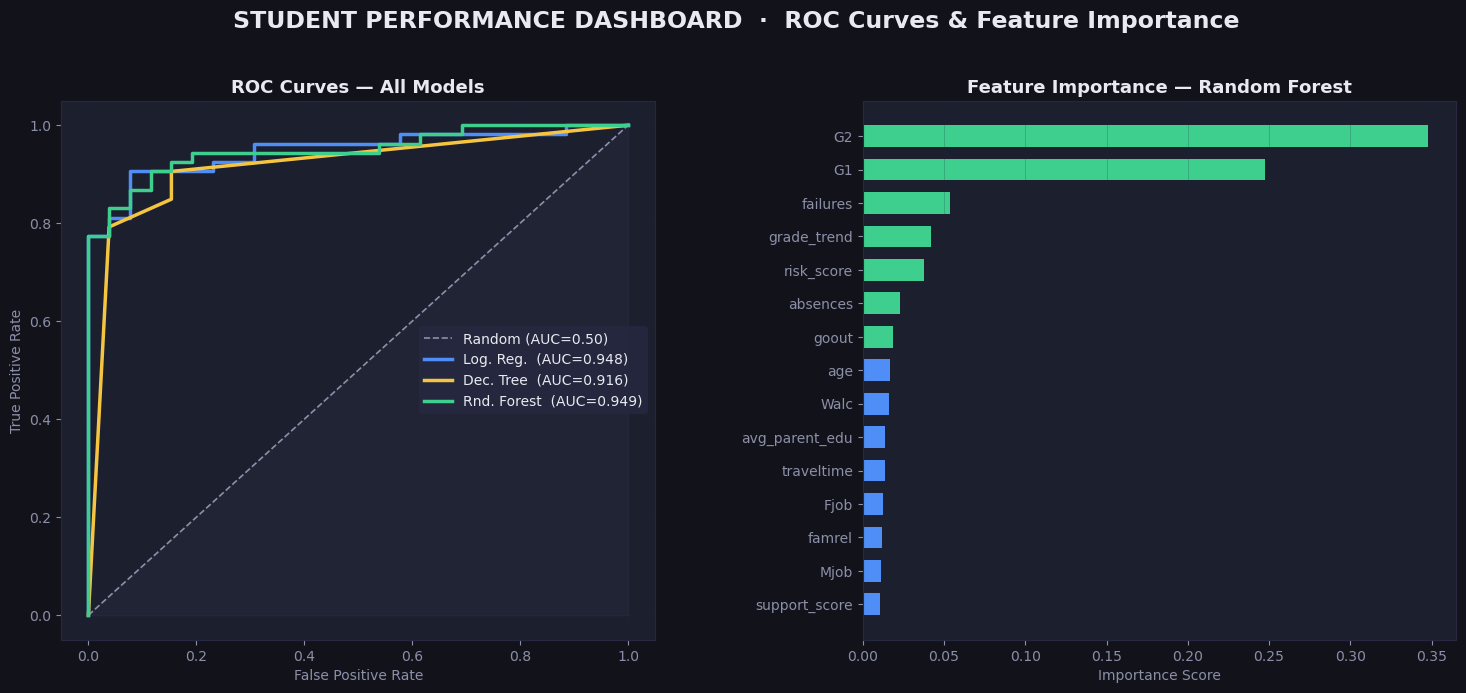

 Panel 5 — ROC & Feature Importance done.


In [26]:
# 9: DASHBOARD PANEL 5 — ROC CURVES & FEATURE IMPORTANCE

fig = plt.figure(figsize=(18, 7), facecolor=DARK)
fig.suptitle('STUDENT PERFORMANCE DASHBOARD  ·  ROC Curves & Feature Importance',
             fontsize=17, fontweight='bold', color=TEXT, y=1.01)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ROC Curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)
ax1.plot([0,1],[0,1],'--', color=MUTED, linewidth=1.2, label='Random (AUC=0.50)')
for name, sname, color in zip(model_names, short_names, m_colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]['prob'])
    ax1.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{sname}  (AUC={results[name]["auc"]:.3f})')
ax1.fill_between([0,1],[0,1], alpha=0.05, color=MUTED)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves — All Models', color=TEXT, fontsize=13, fontweight='bold')
ax1.legend(facecolor=CARD, edgecolor='none', labelcolor=TEXT, fontsize=10)
ax1.grid(True, alpha=0.3)

# Feature Importance (Random Forest)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PANEL)
rf_imp = pd.Series(results['Random Forest']['model'].feature_importances_,
                   index=FEATURES).sort_values(ascending=True).tail(15)
bc_fi = [GREEN if v > rf_imp.median() else BLUE for v in rf_imp.values]
ax2.barh(rf_imp.index, rf_imp.values, color=bc_fi, edgecolor='none', height=0.65)
ax2.set_title('Feature Importance — Random Forest', color=TEXT, fontsize=13, fontweight='bold')
ax2.set_xlabel('Importance Score'); ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard_roc_fi.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Panel 5 — ROC & Feature Importance done.")



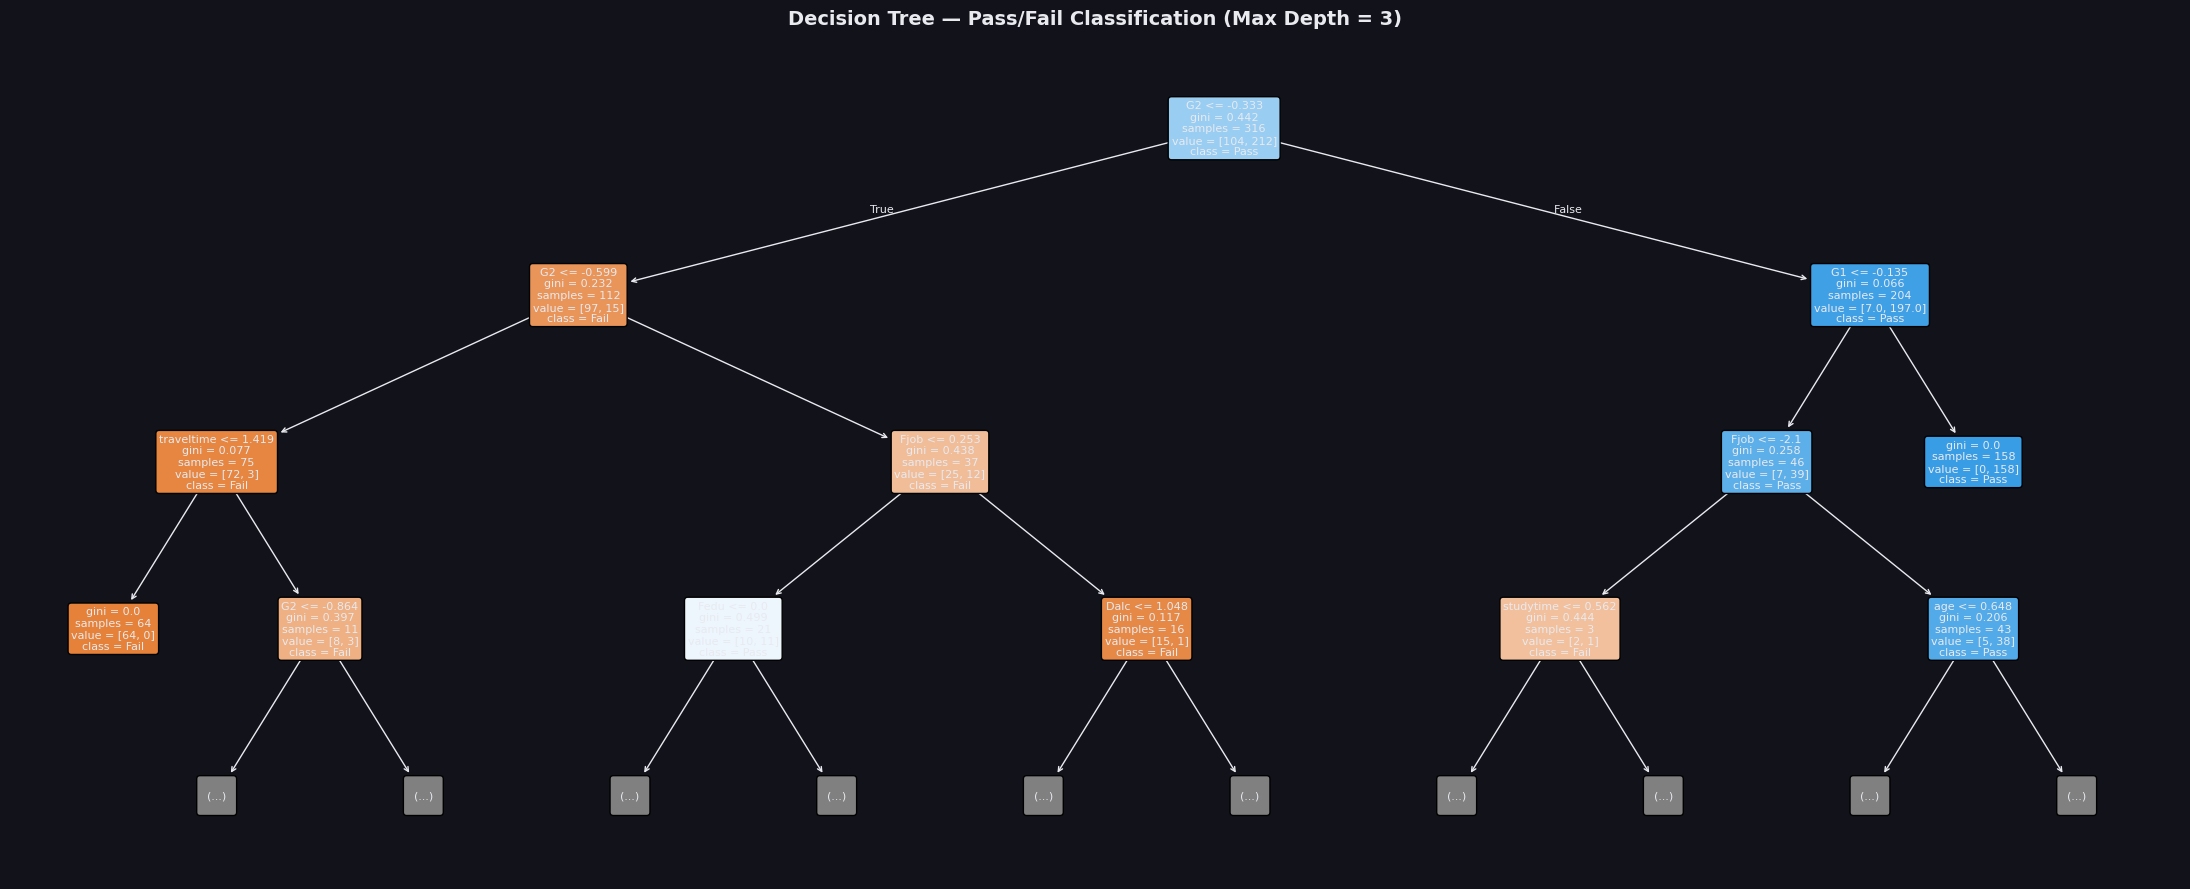

 Decision Tree visualized.


In [27]:
# 10: DECISION TREE VISUALIZATION

fig, ax = plt.subplots(figsize=(22, 9), facecolor=DARK)
ax.set_facecolor(DARK)
plot_tree(results['Decision Tree']['model'],
          feature_names=FEATURES, class_names=['Fail','Pass'],
          filled=True, rounded=True, max_depth=3, ax=ax, fontsize=8)
ax.set_title('Decision Tree — Pass/Fail Classification (Max Depth = 3)',
             color=TEXT, fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('dashboard_dtree.png', dpi=120, bbox_inches='tight', facecolor=DARK)
plt.show()
print(" Decision Tree visualized.")

In [28]:
# 11: CLASSIFICATION REPORTS

for name in model_names:
    print(f'\n{"─"*50}\n  {name}\n{"─"*50}')
    print(classification_report(y_test, results[name]['pred'], target_names=['Fail','Pass']))



──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fail       0.77      0.92      0.84        26
        Pass       0.96      0.87      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.90      0.88        79
weighted avg       0.90      0.89      0.89        79


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fail       0.81      0.85      0.83        26
        Pass       0.92      0.91      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.88      0.87        79
weighted avg       0.89      0.89      0.89        79


──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────

In [29]:
# 12: PREDICT FOR A NEW STUDENT

new_student_raw = {
    'school': 0, 'sex': 1, 'age': 17, 'address': 1, 'famsize': 0, 'Pstatus': 1,
    'Medu': 3, 'Fedu': 2, 'Mjob': 3, 'Fjob': 2, 'reason': 1, 'guardian': 0,
    'traveltime': 1, 'studytime': 3, 'failures': 0, 'schoolsup': 0, 'famsup': 1,
    'paid': 0, 'activities': 1, 'nursery': 1, 'higher': 1, 'internet': 1,
    'romantic': 0, 'famrel': 4, 'freetime': 3, 'goout': 2, 'Dalc': 1,
    'Walc': 2, 'health': 4, 'absences': 3, 'G1': 12, 'G2': 13,
    'grade_trend': 1, 'avg_parent_edu': 2.5, 'risk_score': 1.3, 'support_score': 1
}

ns_df = pd.DataFrame([new_student_raw])[FEATURES]
ns_sc = scaler.transform(ns_df)

print('\n' + '='*52)
print('     PASS / FAIL PREDICTION — NEW STUDENT')
print('='*52)
for name, sname in zip(model_names, short_names):
    pred = results[name]['model'].predict(ns_sc)[0]
    prob = results[name]['model'].predict_proba(ns_sc)[0][1]
    status = 'PASS ' if pred == 1 else 'FAIL ❌'
    print(f'{sname:<16}: {status}   (Pass probability: {prob*100:.1f}%)')
print('='*52)

print('\n  All sections complete. Dashboard images saved.')


     PASS / FAIL PREDICTION — NEW STUDENT
Log. Reg.       : PASS    (Pass probability: 99.8%)
Dec. Tree       : PASS    (Pass probability: 100.0%)
Rnd. Forest     : PASS    (Pass probability: 99.0%)

  All sections complete. Dashboard images saved.
